In [30]:
# to get the image dataset
from keras.datasets import cifar10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

In [31]:
# to see the shape of the input feature array is; dataset x_train consist of
# 50000 images, 32 pixel in height, 32 pixel in width, 3 pixels in depth
# (corresponding in red, green, and blue)
print('x_train shape:', x_train.shape)

x_train shape: (50000, 32, 32, 3)


In [32]:
# to see the shape of the label array
# result show there is 1 label corresponding for each of the 50000 images
print('y_train shape:', y_train.shape)

y_train shape: (50000, 1)


In [34]:
# to see the example of the label and the image; to ptint the first image
print(x_train[0])


[[[ 59  62  63]
  [ 43  46  45]
  [ 50  48  43]
  ...
  [158 132 108]
  [152 125 102]
  [148 124 103]]

 [[ 16  20  20]
  [  0   0   0]
  [ 18   8   0]
  ...
  [123  88  55]
  [119  83  50]
  [122  87  57]]

 [[ 25  24  21]
  [ 16   7   0]
  [ 49  27   8]
  ...
  [118  84  50]
  [120  84  50]
  [109  73  42]]

 ...

 [[208 170  96]
  [201 153  34]
  [198 161  26]
  ...
  [160 133  70]
  [ 56  31   7]
  [ 53  34  20]]

 [[180 139  96]
  [173 123  42]
  [186 144  30]
  ...
  [184 148  94]
  [ 97  62  34]
  [ 83  53  34]]

 [[177 144 116]
  [168 129  94]
  [179 142  87]
  ...
  [216 184 140]
  [151 118  84]
  [123  92  72]]]


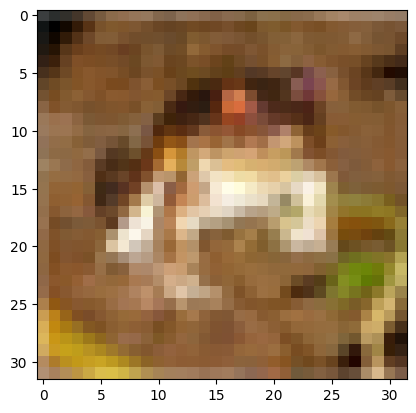

In [35]:
# to visualise image of (x_train[0])
import matplotlib.pyplot as plt
%matplotlib inline
img = plt.imshow(x_train[0])


In [36]:
# the picture not so clear because the pixels is 32 by 32
print('The label is:', y_train[0])


The label is: [6]


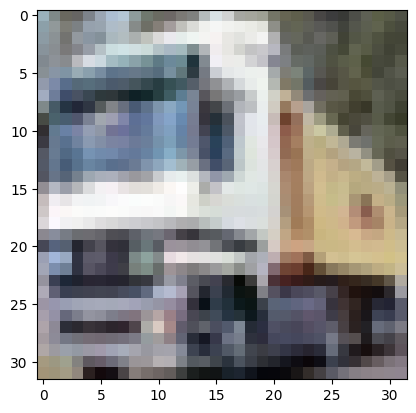

In [37]:
import matplotlib.pyplot as plt
# the above label is 6, e.i a frog; to try anotther label number
img=plt.imshow(x_train[1])

In [38]:
# to display the label number
print('The label is:',y_train[1])

The label is: [9]


In [39]:
# to convert the number of the images into binary numbers
import keras
y_train_one_hot = keras.utils.to_categorical(y_train, 10)
y_test_one_hot = keras.utils.to_categorical(y_test, 10)


In [40]:
# to print the label number in binary formular
print('The one hot label is:', y_train_one_hot[1])


The one hot label is: [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


In [41]:
# to progress image and take step to help in training neuron network
# originally, pixels are between 0 and 255/ new value to be divided by 255
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train = x_train / 255
x_test = x_test / 255


In [42]:
# to test the training in new binary reading
x_train[0]

array([[[0.23137255, 0.24313726, 0.24705882],
        [0.16862746, 0.18039216, 0.1764706 ],
        [0.19607843, 0.1882353 , 0.16862746],
        ...,
        [0.61960787, 0.5176471 , 0.42352942],
        [0.59607846, 0.49019608, 0.4       ],
        [0.5803922 , 0.4862745 , 0.40392157]],

       [[0.0627451 , 0.07843138, 0.07843138],
        [0.        , 0.        , 0.        ],
        [0.07058824, 0.03137255, 0.        ],
        ...,
        [0.48235294, 0.34509805, 0.21568628],
        [0.46666667, 0.3254902 , 0.19607843],
        [0.47843137, 0.34117648, 0.22352941]],

       [[0.09803922, 0.09411765, 0.08235294],
        [0.0627451 , 0.02745098, 0.        ],
        [0.19215687, 0.10588235, 0.03137255],
        ...,
        [0.4627451 , 0.32941177, 0.19607843],
        [0.47058824, 0.32941177, 0.19607843],
        [0.42745098, 0.28627452, 0.16470589]],

       ...,

       [[0.8156863 , 0.6666667 , 0.3764706 ],
        [0.7882353 , 0.6       , 0.13333334],
        [0.7764706 , 0

In [43]:
# Building and training the CNN
# The CNN model architecture for the CIFAR-10 Project (image classification)
# The last layer (the softmax layer) transforms the output of
# the previous layer into probability distribution, which is
# what is expected for the classification problem.
# The model architecture assume zero-pad layer such that the output width and
# height will be the same as the input width and height, called same padding
# Relu activation is used for all the layers except the output which uses
# softmax activation

# Import Keras sequential model.
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D

In [44]:
# call empty sequential model
model = Sequential()

# This is to add layer to an empty sequential model. The 32 refers to
# the depth and 3 pair refers to the width and size. Padding is the same
# as well as the activation which is relu. These apply except the output

model.add(Conv2D(32, (3, 3), activation='relu', padding='same',
input_shape=(32,32,3)))

# There is no need in the second layer to add input size since the input
# and the output are the same
model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))

# The next layer is a max pooling layer with pool size 2 x 2 and stride 2
# (in both dimensions). The default for a max pooling layer stride is
# the pool size. No need to specify stride
model.add(MaxPooling2D(pool_size=(2, 2)))

# The model adds a dropout layer with probability 0.25 of dropout
# so as to prevent overfitting:
model.add(Dropout(0.25))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [45]:
# The next four layers in the model look really similar with exception
# that the depth of the conv layer is 64 instead of 32):
model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

In [46]:
# Third convolutional block (even deeper)
# This Conv2D help to increase the accuracy
model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

In [47]:
# Next in the model is to Flatten the fully connected layer, that is,
# to make the cube like format of neurons into one row.
# At this point, our neurons are spatially arranged in a cube-like
# format
model.add(Flatten())

In [48]:
# Now, the model has a dense (FC) layer of 512 neurons with relu activation:
model.add(Dense(512, activation='relu'))

In [49]:
# Added another dropout of probability 0.5:
model.add(Dropout(0.5))

In [50]:
# Lastly, a dense (FC) layer with 10 neurons and softmax activation:
model.add(Dense(10, activation='softmax'))

In [51]:
# To see the summary of the full model. To run the code
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,341,226 (5.12 MB)

 Trainable params: 1,341,226 (5.12 MB)

 Non-trainable params: 0 (0.00 B)

In [52]:
# Filling in the best numbers
# Compile the model with the settings
# The loss function used is called categorical cross entropy, which is
# applicable for a classification problem of many classes
# The optimizer we use here is Adam. It is a good stochastic gradient
# descent (with a few modifications) so that it trains better

model.compile(loss='categorical_crossentropy', optimizer='adam',
metrics=['accuracy'])

In [53]:
# Running the training of the model
# Train the model with batch size 32 and 20 epochs.
# The setting validation_split=0.2 is used instead of validation_data.
# The dataset percentage used is 20% as a validation set.

hist = model.fit(x_train, y_train_one_hot, batch_size=32, epochs=20,
validation_split=0.2)

Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 330s 261ms/step - accuracy: 0.3634 - loss: 1.7111 - val_accuracy: 0.5080 - val_loss: 1.3617
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 385s 263ms/step - accuracy: 0.5317 - loss: 1.2868 - val_accuracy: 0.6084 - val_loss: 1.1040
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 382s 263ms/step - accuracy: 0.6044 - loss: 1.1070 - val_accuracy: 0.6518 - val_loss: 0.9627
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 331s 265ms/step - accuracy: 0.6461 - loss: 0.9996 - val_accuracy: 0.6855 - val_loss: 0.8809
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 381s 264ms/step - accuracy: 0.6720 - loss: 0.9268 - val_accuracy: 0.7064 - val_loss: 0.8318
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 329s 263ms/step - accuracy: 0.6871 - loss: 0.8790 - val_accuracy: 0.7224 - val_loss: 0.7919
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 385s 266ms/step - accuracy: 0.7094 - loss: 0.8270 - val_accuracy: 0.7251 - val_loss: 0.7820
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 377s 262ms/step - ac

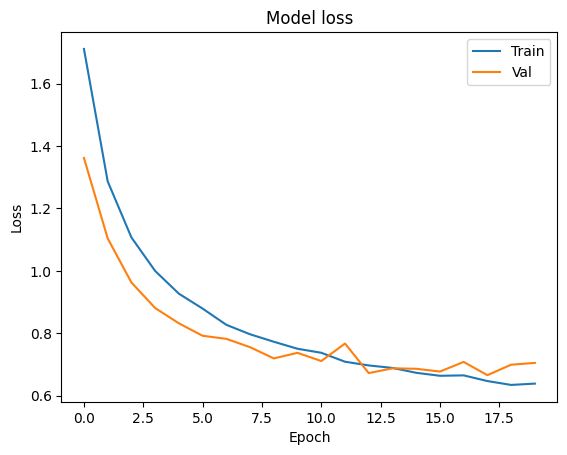

In [54]:
# To visualise the model training and validation loss over the
# number of epochs

plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')
plt.show()

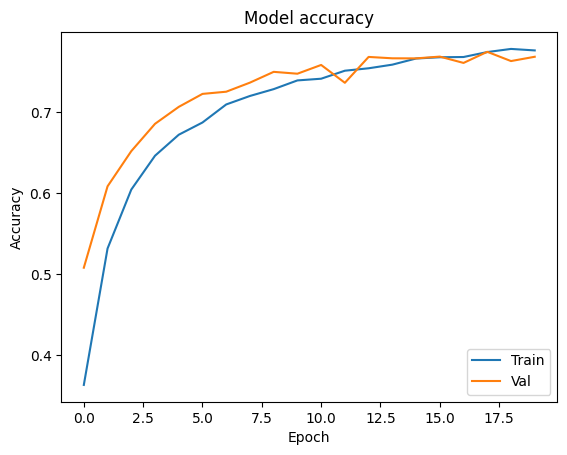

In [55]:
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='lower right')
plt.show()

In [56]:
# Evaluate the model test set after training over the numbers of epochs

model.evaluate(x_test, y_test_one_hot)[1]



313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 66ms/step - accuracy: 0.7621 - loss: 0.7216


0.7620999813079834

In [57]:
# The model will be saved in a file format called HDF5 (with the extension .h5).

model.save('my_cifar10_model.h5')